
Phần 1: Thống kê dữ liệu
1. Hãy sắp xếp dữ liệu điểm DH1 theo thứ tự tăng dần.
2. Hãy sắp xếp dữ liệu điểm DH2 tăng dần theo nhóm giới tính.
3. Hãy tạo pivot-table để thống kê các giá trị count, sum, mean, median, min, max, std, Q1, Q2 và Q3 của DH1 theo KT.
4. Hãy tạo pivot-table để thống kê các giá trị count, sum, mean, median, min, max, std, Q1, Q2 và Q3 của DH1 theo KT và KV.
5. Hãy tạo pivot-table để thống kê các giá trị count, sum, mean, median, min, max, std, Q1, Q2 và Q3 của DH1 theo KT, KV và DT.

In [1]:
pip install pandas numpy tabulate

In [1]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# 0. Đọc dữ liệu từ file CSV
file_name = '/content/dulieuxettuyendaihoc (2).csv'
try:
    df = pd.read_csv(file_name)
    print(f"--- Đã tải thành công tệp dữ liệu '{file_name}' ---")
except FileNotFoundError:
    print(f"Lỗi: Không tìm thấy tệp '{file_name}'. Vui lòng kiểm tra lại đường dẫn!")
    exit()

print("\n" + "="*50 + "\n")

# 1. Sắp xếp dữ liệu điểm DH1 theo thứ tự tăng dần
df_sort_dh1 = df.sort_values(by='DH1')

print("1. KẾT QUẢ SẮP XẾP ĐIỂM DH1 TĂNG DẦN (Trích xuất 5 dòng đầu và 5 dòng cuối):")
print(df_sort_dh1[['STT', 'GT', 'KT', 'KV', 'DH1']].head(5))
print("...")
print(df_sort_dh1[['STT', 'GT', 'KT', 'KV', 'DH1']].tail(5))
print("\n" + "="*50 + "\n")

# 2. Sắp xếp dữ liệu điểm DH2 tăng dần theo nhóm giới tính
df_sort_dh2_gt = df.sort_values(by=['GT', 'DH2'])

print("2. KẾT QUẢ SẮP XẾP ĐIỂM DH2 TĂNG DẦN THEO NHÓM GIỚI TÍNH (Mẫu đầu của mỗi nhóm):")
print("--- Nhóm Nữ (F) tiêu biểu ---")
print(df_sort_dh2_gt[df_sort_dh2_gt['GT'] == 'F'][['STT', 'GT', 'DH2']].head(5))
print("\n--- Nhóm Nam (M) tiêu biểu ---")
print(df_sort_dh2_gt[df_sort_dh2_gt['GT'] == 'M'][['STT', 'GT', 'DH2']].head(5))
print("\n" + "="*50 + "\n")

# ĐỊNH NGHĨA CÁC HÀM THỐNG KÊ CHO PIVOT TABLE
def q1(x):
    return x.quantile(0.25)

def q2(x):
    return x.quantile(0.50)

def q3(x):
    return x.quantile(0.75)

# Danh sách hàm bao gồm các hàm mặc định của pandas và các hàm tứ phân vị tự định nghĩa
agg_funcs = ['count', 'sum', 'mean', 'median', 'min', 'max', 'std', q1, q2, q3]
column_names = ['Count', 'Sum', 'Mean', 'Median', 'Min', 'Max', 'Std', 'Q1', 'Q2', 'Q3']

# 3. Pivot-table thống kê các giá trị của DH1 theo KT
pivot_kt = df.pivot_table(values='DH1', index='KT', aggfunc=agg_funcs)
pivot_kt.columns = column_names

print("3. BẢNG PIVOT-TABLE THỐNG KÊ ĐIỂM DH1 THEO KHỐI THI (KT):")
print(pivot_kt.round(2))
print("\n" + "="*50 + "\n")

# 4. Pivot-table thống kê các giá trị của DH1 theo KT và KV
pivot_kt_kv = df.pivot_table(values='DH1', index=['KT', 'KV'], aggfunc=agg_funcs)
pivot_kt_kv.columns = column_names

print("4. BẢNG PIVOT-TABLE THỐNG KÊ ĐIỂM DH1 THEO KHỐI THI (KT) VÀ KHU VỰC (KV):")
print(pivot_kt_kv.round(2))
print("\n" + "="*50 + "\n")

# 5. Pivot-table thống kê các giá trị của DH1 theo KT, KV và DT
pivot_kt_kv_dt = df.pivot_table(values='DH1', index=['KT', 'KV', 'DT'], aggfunc=agg_funcs)

pivot_kt_kv_dt.columns = ['Count', 'Sum', 'Mean', 'Median', 'Min', 'Max', 'Q1', 'Q2', 'Q3']

print("5. BẢNG PIVOT-TABLE THỐNG KÊ ĐIỂM DH1 THEO KT, KV VÀ DÂN TỘC (DT):")
print(pivot_kt_kv_dt.round(2))
print("\n" + "="*50 + "\n")
print("--- HOÀN THÀNH QUÁ TRÌNH XỬ LÝ VÀ THỐNG KÊ ---")

--- Đã tải thành công tệp dữ liệu '/content/dulieuxettuyendaihoc (2).csv' ---


1. KẾT QUẢ SẮP XẾP ĐIỂM DH1 TĂNG DẦN (Trích xuất 5 dòng đầu và 5 dòng cuối):
    STT GT  KT KV   DH1
53   54  M   A  1  1.00
43   44  F  D1  2  1.25
5     6  M  D1  1  1.50
72   73  M   A  1  1.50
83   84  F   B  1  1.75
...
    STT GT  KT   KV   DH1
6     7  F   C    2  6.50
11   12  M  D1    2  6.75
23   24  M   C  2NT  6.75
24   25  F   C    1  7.00
97   98  M   C  2NT  7.00


2. KẾT QUẢ SẮP XẾP ĐIỂM DH2 TĂNG DẦN THEO NHÓM GIỚI TÍNH (Mẫu đầu của mỗi nhóm):
--- Nhóm Nữ (F) tiêu biểu ---
    STT GT   DH2
95   96  F  1.50
25   26  F  2.00
24   25  F  2.25
46   47  F  2.25
13   14  F  2.75

--- Nhóm Nam (M) tiêu biểu ---
    STT GT   DH2
94   95  M  2.50
99  100  M  2.50
62   63  M  2.75
15   16  M  3.00
38   39  M  3.00


3. BẢNG PIVOT-TABLE THỐNG KÊ ĐIỂM DH1 THEO KHỐI THI (KT):
    Count     Sum  Mean  Median   Min   Max   Std    Q1    Q2    Q3
KT                                                            

Phần 2: Trình bày dữ liệu
1. Hãy trình bày dữ liệu biến: GT
Gợi ý
- Lập bảng tần số và tần suất
- Vẽ biểu đồ tần số (cột), biểu đồ tần suất (tròn).
2. Hãy trình bày dữ liệu lần lượt các biến: US_TBM1, US_TBM2 và US_TBM3
3. Hãy trình bày dữ liệu biến DT với các học sinh là nam
4. Hãy trình bày dữ liệu biến KV với các học sinh là nam thuộc dân tộc Kinh, có điểm thỏa
mãn điều kiện (DH1 >= 5.0 và DH2 >= 4.0 và DH3 >= 4.0)
5. Hãy trình bày dữ liệu lần lượt các biến DH1, DH2, DH3 lớn hơn bằng 5.0 và thuộc khu
vực 2NT


THỰC HIỆN PHẦN 2: TRÌNH BÀY VÀ TRỰC QUAN HÓA DỮ LIỆU

1. TRÌNH BÀY DỮ LIỆU BIẾN GIỚI TÍNH (GT):
| GT   |   Tần số (Số lượng) |   Tần suất (%) |
|:-----|--------------------:|---------------:|
| M    |                  52 |             52 |
| F    |                  48 |             48 |


/tmp/ipykernel_5563/3703621849.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tb_gt.index, y=tb_gt['Tần số (Số lượng)'], ax=axes[0], palette='Set2')


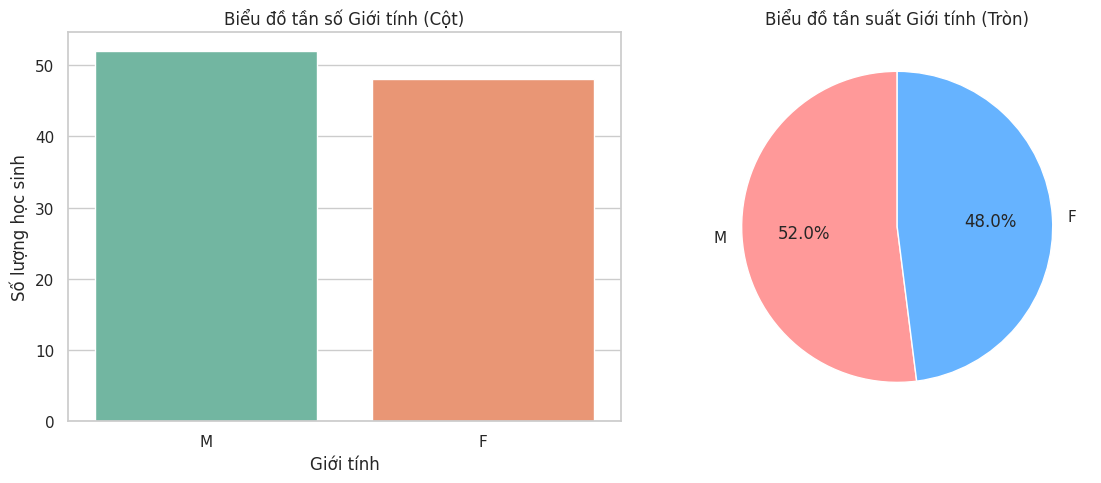


2. TRÌNH BÀY DỮ LIỆU BIẾN US_TBM1, US_TBM2, US_TBM3 (Thang điểm Mỹ):
|       |    US_TBM1 |    US_TBM2 |    US_TBM3 |
|:------|-----------:|-----------:|-----------:|
| count | 100        | 100        | 100        |
| mean  |   2.4498   |   2.57495  |   2.5587   |
| std   |   0.390875 |   0.372322 |   0.374236 |
| min   |   1.655    |   1.725    |   1.54     |
| 25%   |   2.1425   |   2.24875  |   2.3      |
| 50%   |   2.5125   |   2.5825   |   2.575    |
| 75%   |   2.74375  |   2.8625   |   2.84125  |
| max   |   3.23     |   3.405    |   3.29     |


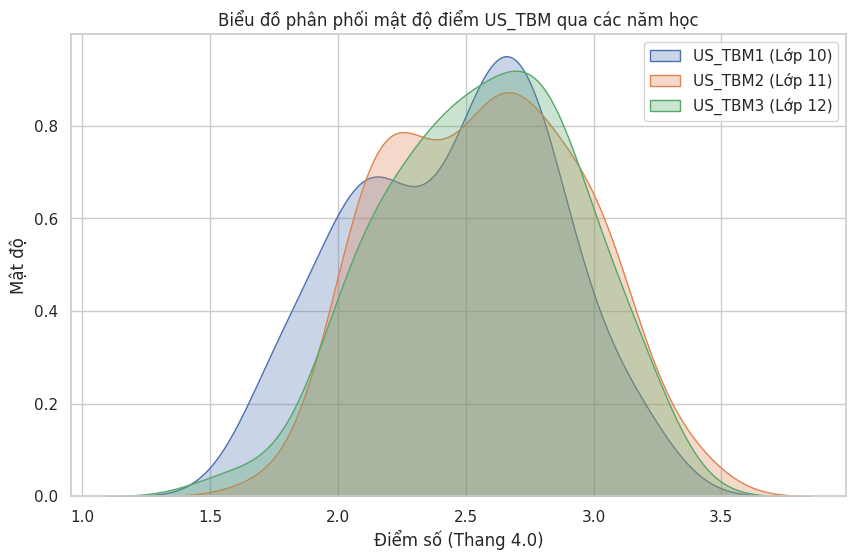


3. TRÌNH BÀY DỮ LIỆU BIẾN DÂN TỘC (DT) CỦA CÁC HỌC SINH NAM:
|   DT_Filled |   Tần số (Số lượng Nam) |   Tần suất (%) |
|------------:|------------------------:|---------------:|
|           1 |                      51 |       98.0769  |
|           6 |                       1 |        1.92308 |


/tmp/ipykernel_5563/3703621849.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_nam, x='DT_Filled', palette='Pastel1')


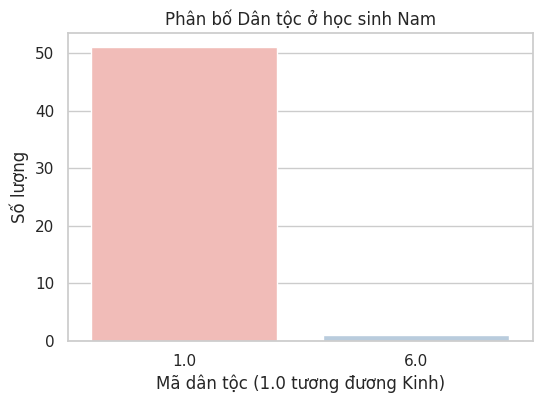


4. TRÌNH BÀY DỮ LIỆU BIẾN KHU VỰC (KV) THỎA MÃN ĐIỀU KIỆN PHỨC TẠP:
| KV   |   Tần số |   Tần suất (%) |
|:-----|---------:|---------------:|
| 1    |        2 |        33.3333 |
| 2    |        2 |        33.3333 |
| 2NT  |        2 |        33.3333 |


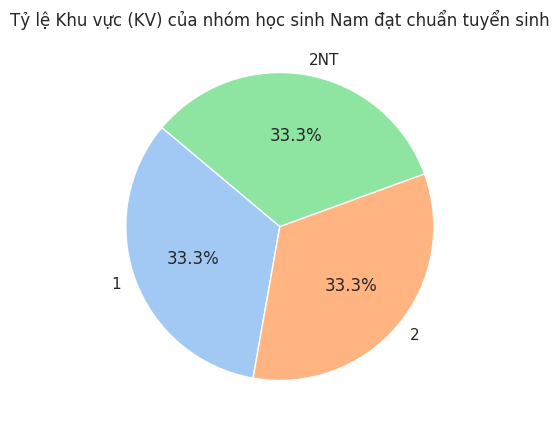


5. TRÌNH BÀY DỮ LIỆU ĐIỂM THI ĐẠI HỌC (>= 5.0) TẠI KHU VỰC 2NT:
| Môn thi   |   Số lượng đạt (>= 5.0) |   Tỷ lệ đạt / Tổng số dân 2NT (%) |
|:----------|------------------------:|----------------------------------:|
| DH1       |                       4 |                           19.0476 |
| DH2       |                       6 |                           28.5714 |
| DH3       |                       6 |                           28.5714 |


/tmp/ipykernel_5563/3703621849.py:135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tb_dh_2nt, x='Môn thi', y='Số lượng đạt (>= 5.0)', palette='viridis')


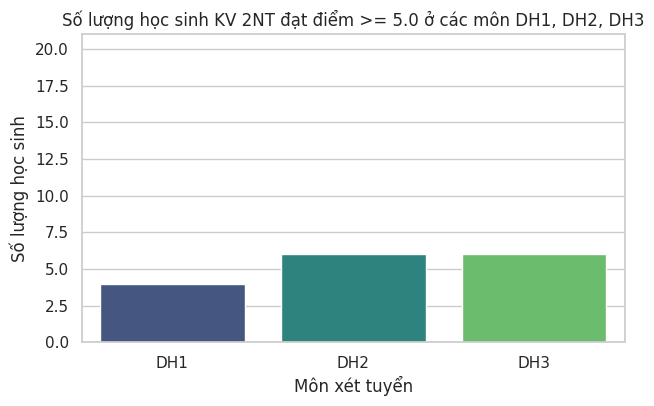

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid")

# 0. Tải dữ liệu
file_name = 'dulieuxettuyendaihoc (2).csv'
df = pd.read_csv(file_name)

df['DT_Filled'] = df['DT'].fillna(1.0)

print("="*60)
print("THỰC HIỆN PHẦN 2: TRÌNH BÀY VÀ TRỰC QUAN HÓA DỮ LIỆU")
print("="*60)

# 1. Trình bày dữ liệu biến: GT
print("\n1. TRÌNH BÀY DỮ LIỆU BIẾN GIỚI TÍNH (GT):")
tb_gt_frequence = df['GT'].value_counts()
tb_gt_ratio = df['GT'].value_counts(normalize=True) * 100

tb_gt = pd.DataFrame({
    'Tần số (Số lượng)': tb_gt_frequence,
    'Tần suất (%)': tb_gt_ratio
})
print(tb_gt.to_markdown())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x=tb_gt.index, y=tb_gt['Tần số (Số lượng)'], ax=axes[0], palette='Set2')
axes[0].set_title('Biểu đồ tần số Giới tính (Cột)')
axes[0].set_xlabel('Giới tính')
axes[0].set_ylabel('Số lượng học sinh')

axes[1].pie(tb_gt['Tần suất (%)'], labels=tb_gt.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
axes[1].set_title('Biểu đồ tần suất Giới tính (Tròn)')

plt.tight_layout()
plt.show()


# 2. Trình bày dữ liệu các biến: US_TBM1, US_TBM2 và US_TBM3
print("\n2. TRÌNH BÀY DỮ LIỆU BIẾN US_TBM1, US_TBM2, US_TBM3 (Thang điểm Mỹ):")

mon_hoc_1 = ['T1', 'L1', 'H1', 'S1', 'V1', 'X1', 'D1', 'N1']
mon_hoc_2 = ['T2', 'L2', 'H2', 'S2', 'V2', 'X2', 'D2', 'N2']
mon_hoc_3 = ['T3', 'L3', 'H3', 'S3', 'V3', 'X3', 'D3', 'N3']

df['TBM1'] = df[mon_hoc_1].mean(axis=1)
df['TBM2'] = df[mon_hoc_2].mean(axis=1)
df['TBM3'] = df[mon_hoc_3].mean(axis=1)

df['US_TBM1'] = (df['TBM1'] / 10) * 4
df['US_TBM2'] = (df['TBM2'] / 10) * 4
df['US_TBM3'] = (df['TBM3'] / 10) * 4

print(df[['US_TBM1', 'US_TBM2', 'US_TBM3']].describe().to_markdown())

plt.figure(figsize=(10, 6))
sns.kdeplot(df['US_TBM1'], label='US_TBM1 (Lớp 10)', fill=True, alpha=0.3)
sns.kdeplot(df['US_TBM2'], label='US_TBM2 (Lớp 11)', fill=True, alpha=0.3)
sns.kdeplot(df['US_TBM3'], label='US_TBM3 (Lớp 12)', fill=True, alpha=0.3)
plt.title('Biểu đồ phân phối mật độ điểm US_TBM qua các năm học')
plt.xlabel('Điểm số (Thang 4.0)')
plt.ylabel('Mật độ')
plt.legend()
plt.show()


# 3. Trình bày dữ liệu biến DT với các học sinh là nam
print("\n3. TRÌNH BÀY DỮ LIỆU BIẾN DÂN TỘC (DT) CỦA CÁC HỌC SINH NAM:")
df_nam = df[df['GT'] == 'M']
tb_dt_nam_freq = df_nam['DT_Filled'].value_counts()
tb_dt_nam_ratio = df_nam['DT_Filled'].value_counts(normalize=True) * 100

tb_dt_nam = pd.DataFrame({
    'Tần số (Số lượng Nam)': tb_dt_nam_freq,
    'Tần suất (%)': tb_dt_nam_ratio
})
print(tb_dt_nam.to_markdown())

plt.figure(figsize=(6, 4))
sns.countplot(data=df_nam, x='DT_Filled', palette='Pastel1')
plt.title('Phân bố Dân tộc ở học sinh Nam')
plt.xlabel('Mã dân tộc (1.0 tương đương Kinh)')
plt.ylabel('Số lượng')
plt.show()


# 4. Trình bày dữ liệu biến KV với các học sinh là nam thuộc dân tộc Kinh, thỏa điều kiện: DH1 >= 5.0 và DH2 >= 4.0 và DH3 >= 4.0
print("\n4. TRÌNH BÀY DỮ LIỆU BIẾN KHU VỰC (KV) THỎA MÃN ĐIỀU KIỆN PHỨC TẠP:")

cond_4 = (df['GT'] == 'M') & (df['DT_Filled'] == 1.0) & (df['DH1'] >= 5.0) & (df['DH2'] >= 4.0) & (df['DH3'] >= 4.0)
df_cond_4 = df[cond_4]

if df_cond_4.empty:
    print("-> Không có học sinh nam dân tộc Kinh nào thỏa mãn đồng thời điều kiện điểm số trên.")
else:
    tb_kv_cond4 = pd.DataFrame({
        'Tần số': df_cond_4['KV'].value_counts(),
        'Tần suất (%)': df_cond_4['KV'].value_counts(normalize=True) * 100
    })
    print(tb_kv_cond4.to_markdown())

    plt.figure(figsize=(6, 5))
    plt.pie(tb_kv_cond4['Tần suất (%)'], labels=tb_kv_cond4.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
    plt.title('Tỷ lệ Khu vực (KV) của nhóm học sinh Nam đạt chuẩn tuyển sinh')
    plt.show()


# 5. Trình bày dữ liệu lần lượt các biến DH1, DH2, DH3 lớn hơn bằng 5.0 và thuộc khu vực 2NT
print("\n5. TRÌNH BÀY DỮ LIỆU ĐIỂM THI ĐẠI HỌC (>= 5.0) TẠI KHU VỰC 2NT:")

df_2nt = df[df['KV'] == '2NT']

count_dh1 = (df_2nt['DH1'] >= 5.0).sum()
count_dh2 = (df_2nt['DH2'] >= 5.0).sum()
count_dh3 = (df_2nt['DH3'] >= 5.0).sum()

tb_dh_2nt = pd.DataFrame({
    'Môn thi': ['DH1', 'DH2', 'DH3'],
    'Số lượng đạt (>= 5.0)': [count_dh1, count_dh2, count_dh3],
    'Tỷ lệ đạt / Tổng số dân 2NT (%)': [
        (count_dh1 / len(df_2nt)) * 100,
        (count_dh2 / len(df_2nt)) * 100,
        (count_dh3 / len(df_2nt)) * 100
    ]
})
print(tb_dh_2nt.to_markdown(index=False))

plt.figure(figsize=(7, 4))
sns.barplot(data=tb_dh_2nt, x='Môn thi', y='Số lượng đạt (>= 5.0)', palette='viridis')
plt.title('Số lượng học sinh KV 2NT đạt điểm >= 5.0 ở các môn DH1, DH2, DH3')
plt.xlabel('Môn xét tuyển')
plt.ylabel('Số lượng học sinh')
plt.ylim(0, len(df_2nt))
plt.show()

Phần 3: Trực quan hóa dữ liệu theo nhóm phân loại
1. Trực quan dữ liệu học sinh nữ trên các nhóm XL1, XL2, XL3 dạng unstacked
Gợi ý
- Lọc dữ liệu giới tính là nữ
- Oy: Chiều cao biểu đồ cột thể hiển số lượng học sinh theo xếp loại
- Màu sắc thể hiện giá trị xếp loại: [Y, TB, K, G, XS]
- Ox: thể hiện nhóm XL1, XL2 và XL3
2. Trực quan dữ liệu KQXT trên nhóm học sinh có khối thi A, A1, B thuộc khu vực 1, 2
3. Trực quan dữ liệu số lượng thí sinh từng khu vực dựa trên từng nhóm khối thi
4. Trực quan dữ liệu số lượng thí sinh đậu, rớt trên từng nhóm khối thi
5. Trực quan dữ liệu số lượng thí sinh đậu rớt trên từng nhóm khu vực.
6. Trực quan dữ liệu số lượng thí sinh đậu rớt dựa trên từng nhóm dân tộc
7. Trực quan dữ liệu số lượng thí sinh đậu rớt dựa trên từng nhóm giới tính.

--- Hoàn thành tiền xử lý dữ liệu. Bắt đầu vẽ biểu đồ từng câu ---


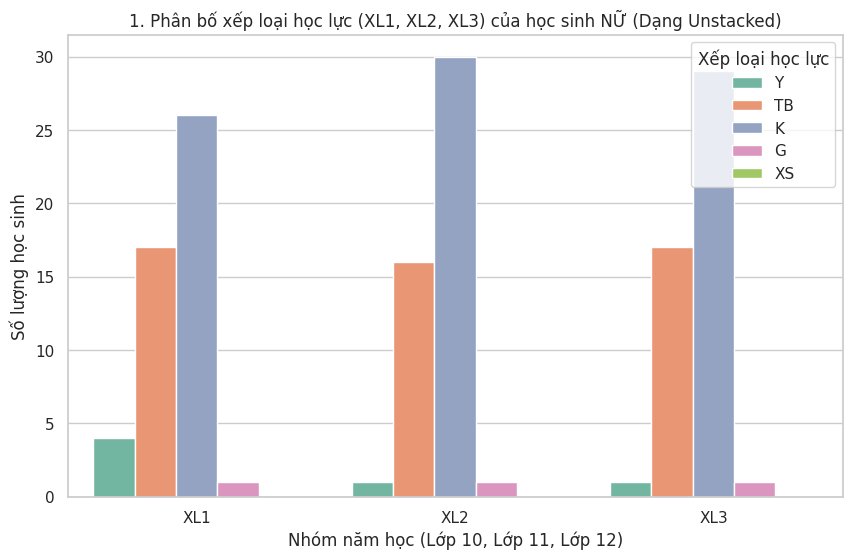

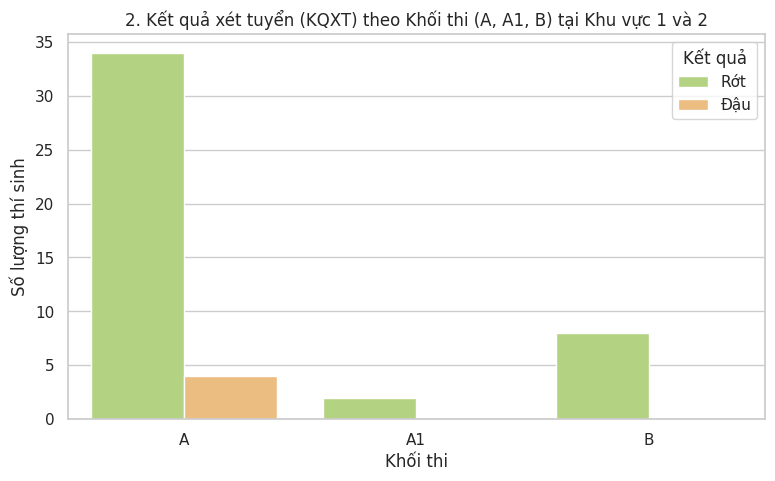

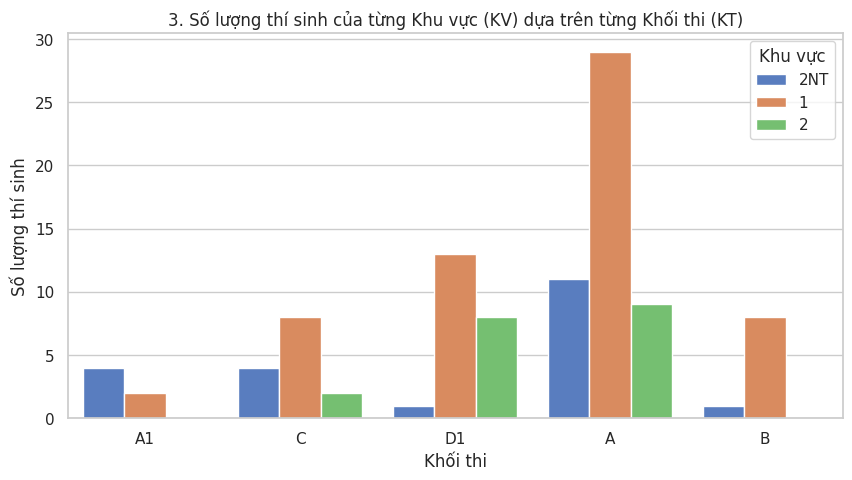

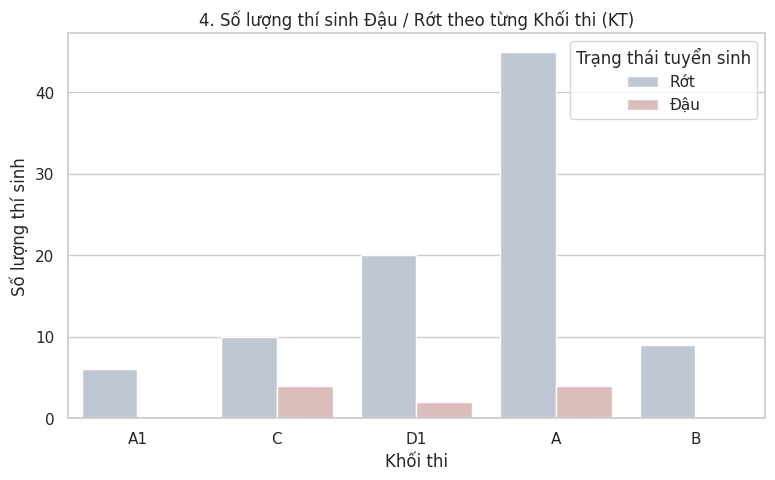

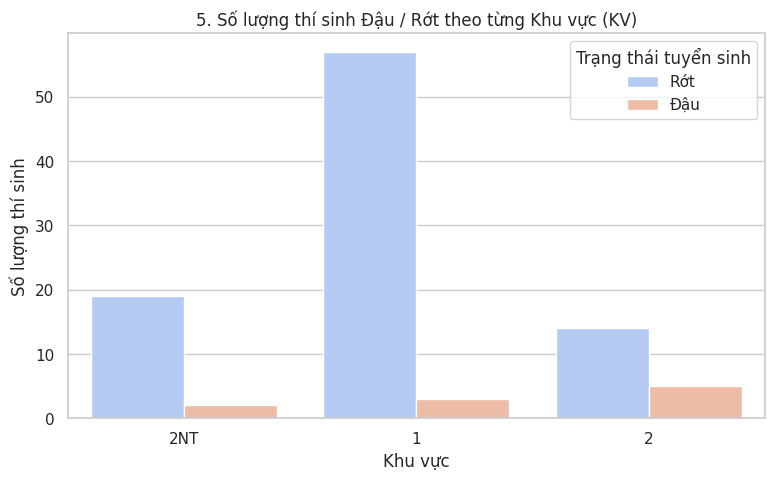

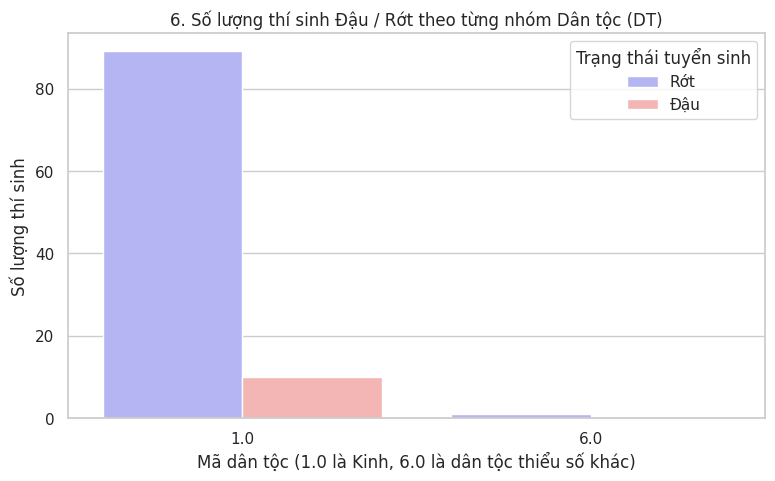

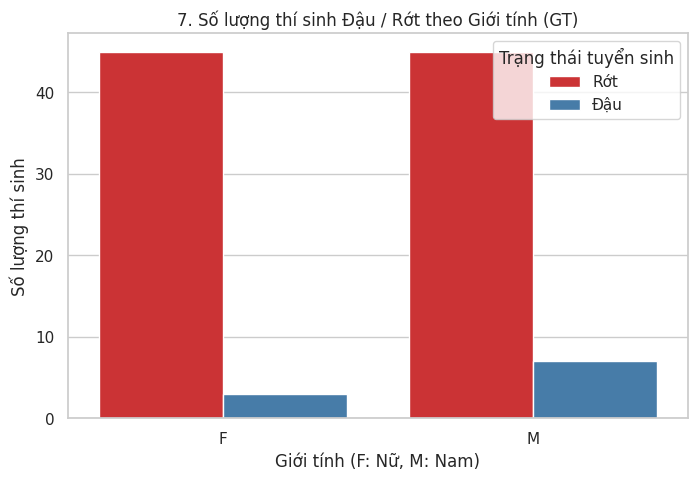

--- Đã thực hiện trực quan hóa thành công cả 7 biểu đồ phân loại ---


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid")

# 0. Tải dữ liệu gốc
file_name = 'dulieuxettuyendaihoc (2).csv'
df = pd.read_csv(file_name)

mon_hoc_1 = ['T1', 'L1', 'H1', 'S1', 'V1', 'X1', 'D1', 'N1']
mon_hoc_2 = ['T2', 'L2', 'H2', 'S2', 'V2', 'X2', 'D2', 'N2']
mon_hoc_3 = ['T3', 'L3', 'H3', 'S3', 'V3', 'X3', 'D3', 'N3']

df['TBM1'] = df[mon_hoc_1].mean(axis=1)
df['TBM2'] = df[mon_hoc_2].mean(axis=1)
df['TBM3'] = df[mon_hoc_3].mean(axis=1)

def phan_loai_hoc_luc(diem):
    if diem >= 9.0: return 'XS'
    elif diem >= 8.0: return 'G'
    elif diem >= 6.5: return 'K'
    elif diem >= 5.0: return 'TB'
    else: return 'Y'

df['XL1'] = df['TBM1'].apply(phan_loai_hoc_luc)
df['XL2'] = df['TBM2'].apply(phan_loai_hoc_luc)
df['XL3'] = df['TBM3'].apply(phan_loai_hoc_luc)

df['Tong_DH'] = df['DH1'] + df['DH2'] + df['DH3']
df['KQXT'] = np.where((df['Tong_DH'] >= 15.0) & (df['DH1'] > 1.0) & (df['DH2'] > 1.0) & (df['DH3'] > 1.0), 'Đậu', 'Rớt')

df['DT_Filled'] = df['DT'].fillna(1.0).astype(str)

print("--- Hoàn thành tiền xử lý dữ liệu. Bắt đầu vẽ biểu đồ từng câu ---")

# 1. Trực quan dữ liệu học sinh nữ trên các nhóm XL1, XL2, XL3 dạng unstacked
df_nu = df[df['GT'] == 'F']

df_xl_nu = df_nu[['XL1', 'XL2', 'XL3']].melt(var_name='Học kỳ', value_name='Xếp loại')

plt.figure(figsize=(10, 6))
order_xl = ['Y', 'TB', 'K', 'G', 'XS']
sns.countplot(data=df_xl_nu, x='Học kỳ', hue='Xếp loại', hue_order=order_xl, palette='Set2')

plt.title('1. Phân bố xếp loại học lực (XL1, XL2, XL3) của học sinh NỮ (Dạng Unstacked)')
plt.xlabel('Nhóm năm học (Lớp 10, Lớp 11, Lớp 12)')
plt.ylabel('Số lượng học sinh')
plt.legend(title='Xếp loại học lực')
plt.show()


# 2. Trực quan dữ liệu KQXT trên nhóm học sinh khối thi A, A1, B thuộc khu vực 1, 2
cond_2 = df['KT'].isin(['A', 'A1', 'B']) & df['KV'].isin(['1', '2'])
df_q2 = df[cond_2]

plt.figure(figsize=(9, 5))
sns.countplot(data=df_q2, x='KT', hue='KQXT', palette='RdYlGn_r')
plt.title('2. Kết quả xét tuyển (KQXT) theo Khối thi (A, A1, B) tại Khu vực 1 và 2')
plt.xlabel('Khối thi')
plt.ylabel('Số lượng thí sinh')
plt.legend(title='Kết quả')
plt.show()


# 3. Trực quan dữ liệu số lượng thí sinh từng khu vực dựa trên từng nhóm khối thi
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='KT', hue='KV', palette='muted')
plt.title('3. Số lượng thí sinh của từng Khu vực (KV) dựa trên từng Khối thi (KT)')
plt.xlabel('Khối thi')
plt.ylabel('Số lượng thí sinh')
plt.legend(title='Khu vực')
plt.show()


# 4. Trực quan dữ liệu số lượng thí sinh đậu, rớt trên từng nhóm khối thi
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='KT', hue='KQXT', palette='vlag')
plt.title('4. Số lượng thí sinh Đậu / Rớt theo từng Khối thi (KT)')
plt.xlabel('Khối thi')
plt.ylabel('Số lượng thí sinh')
plt.legend(title='Trạng thái tuyển sinh')
plt.show()


# 5. Trực quan dữ liệu số lượng thí sinh đậu rớt trên từng nhóm khu vực
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='KV', hue='KQXT', palette='coolwarm')
plt.title('5. Số lượng thí sinh Đậu / Rớt theo từng Khu vực (KV)')
plt.xlabel('Khu vực')
plt.ylabel('Số lượng thí sinh')
plt.legend(title='Trạng thái tuyển sinh')
plt.show()


# 6. Trực quan dữ liệu số lượng thí sinh đậu rớt dựa trên từng nhóm dân tộc
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='DT_Filled', hue='KQXT', palette='bwr')
plt.title('6. Số lượng thí sinh Đậu / Rớt theo từng nhóm Dân tộc (DT)')
plt.xlabel('Mã dân tộc (1.0 là Kinh, 6.0 là dân tộc thiểu số khác)')
plt.ylabel('Số lượng thí sinh')
plt.legend(title='Trạng thái tuyển sinh')
plt.show()


# 7. Trực quan dữ liệu số lượng thí sinh đậu rớt dựa trên từng nhóm giới tính
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='GT', hue='KQXT', palette='Set1')
plt.title('7. Số lượng thí sinh Đậu / Rớt theo Giới tính (GT)')
plt.xlabel('Giới tính (F: Nữ, M: Nam)')
plt.ylabel('Số lượng thí sinh')
plt.legend(title='Trạng thái tuyển sinh')
plt.show()

print("--- Đã thực hiện trực quan hóa thành công cả 7 biểu đồ phân loại ---")

Phần 4: Trực quan hóa dữ liệu nâng cao


--- Đã tải thành công tệp dữ liệu 'dulieuxettuyendaihoc (2).csv' ---

THỰC HIỆN PHẦN 4: TRỰC QUAN HÓA DỮ LIỆU NÂNG CAO (ĐÃ SỬA LỖI RỐI DÂY)



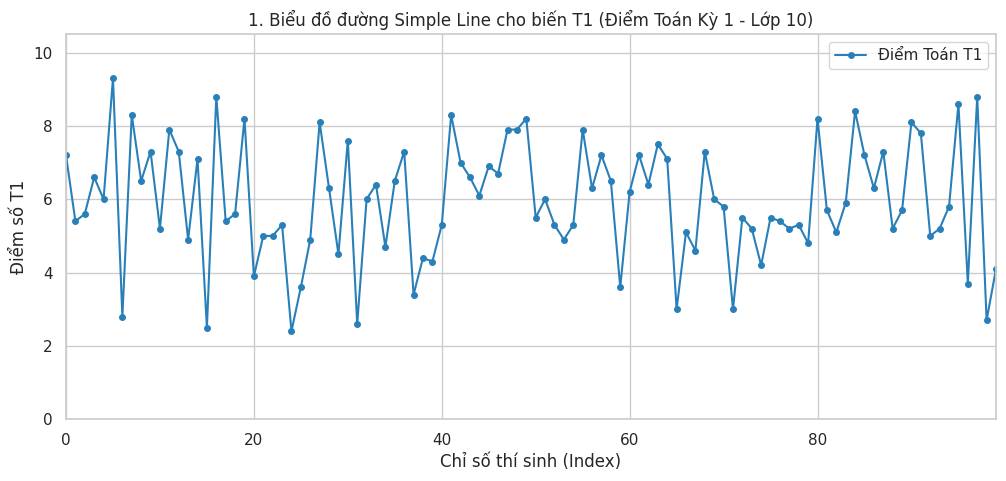

3. BẢNG TẦN SỐ CHO BIẾN PHANLOPT1:
| Xếp loại Toán (T1)   |   Tần số (Số lượng) |
|:---------------------|--------------------:|
| kém                  |                  23 |
| tb                   |                  46 |
| khá                  |                  19 |
| g                    |                  12 |




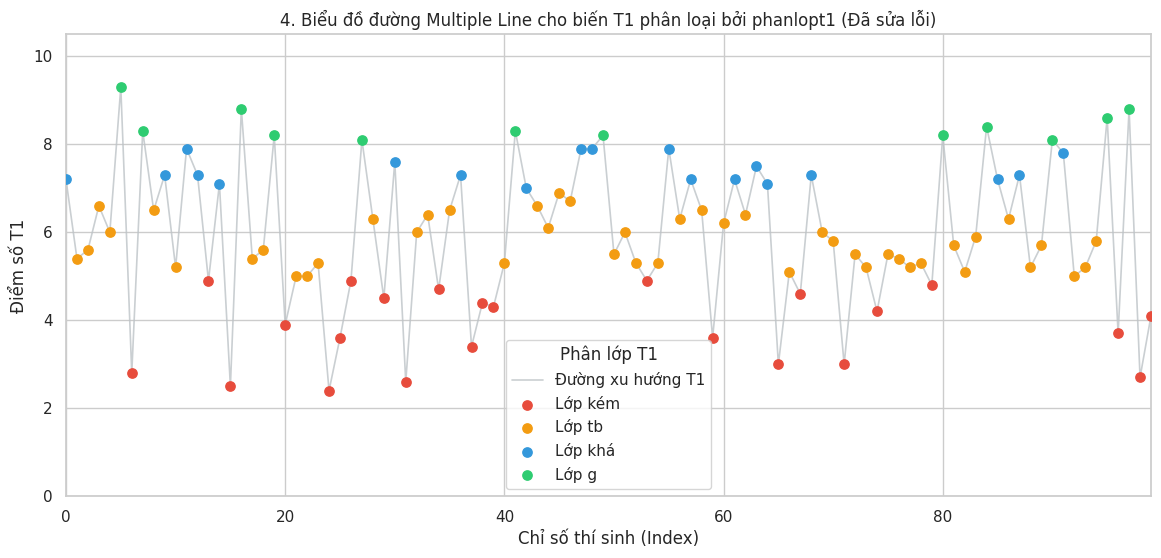

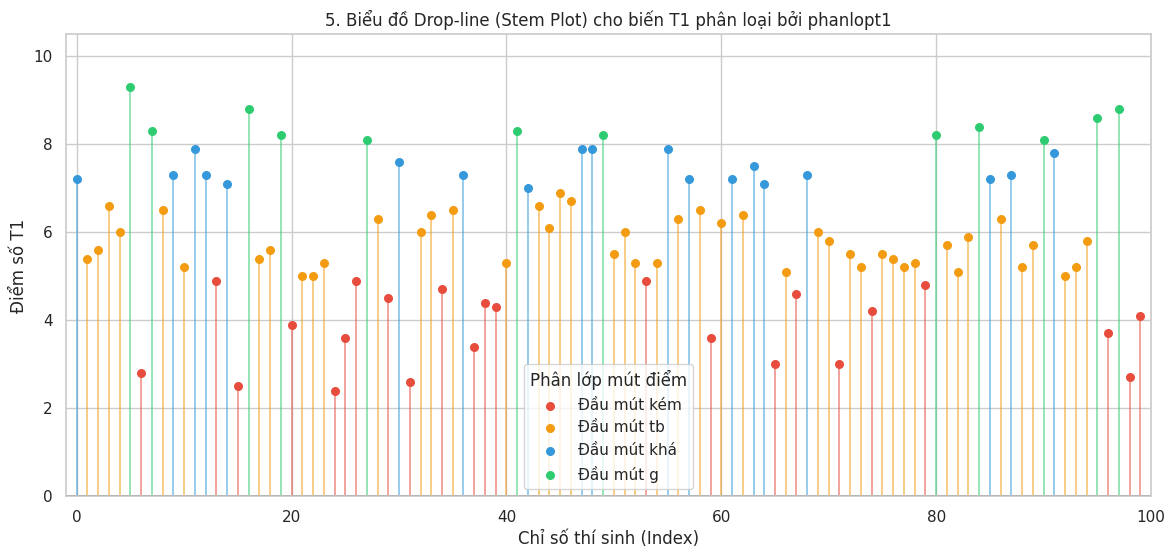

--- HOÀN THÀNH CHƯƠNG TRÌNH THỰC HÀNH PHẦN 4 CHUẨN XÁC ---


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid")

# 0. Tải dữ liệu gốc
file_name = 'dulieuxettuyendaihoc (2).csv'
try:
    df = pd.read_csv(file_name)
    print(f"--- Đã tải thành công tệp dữ liệu '{file_name}' ---")
except FileNotFoundError:
    print(f"Lỗi: Không tìm thấy tệp '{file_name}'. Vui lòng kiểm tra lại đường dẫn!")
    exit()

print("\n" + "="*60)
print("THỰC HIỆN PHẦN 4: TRỰC QUAN HÓA DỮ LIỆU NÂNG CAO (ĐÃ SỬA LỖI RỐI DÂY)")
print("="*60 + "\n")


# 1. Vẽ biểu đồ đường Simple cho biến T1
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['T1'], marker='o', color='#2980b9', linestyle='-', linewidth=1.5, markersize=4, label='Điểm Toán T1')

plt.title('1. Biểu đồ đường Simple Line cho biến T1 (Điểm Toán Kỳ 1 - Lớp 10)')
plt.xlabel('Chỉ số thí sinh (Index)')
plt.ylabel('Điểm số T1')
plt.xlim(0, len(df)-1)
plt.ylim(0, 10.5)
plt.legend()
plt.show()

# 2. Tạo biến phân loại (phanlopt1) cho môn toán (T1)
def phan_lop_t1(diem):
    if diem < 5.0:
        return 'kém'
    elif diem < 7.0:
        return 'tb'
    elif diem < 8.0:
        return 'khá'
    else:
        return 'g'

df['phanlopt1'] = df['T1'].apply(phan_lop_t1)

# 3. Lập bảng tần số cho biến phanlopt1
print("3. BẢNG TẦN SỐ CHO BIẾN PHANLOPT1:")
tan_so_t1 = df['phanlopt1'].value_counts()
order_categories = ['kém', 'tb', 'khá', 'g']
tan_so_t1 = tan_so_t1.reindex(order_categories, fill_value=0)

tb_tan_so = pd.DataFrame({
    'Xếp loại Toán (T1)': tan_so_t1.index,
    'Tần số (Số lượng)': tan_so_t1.values
})
print(tb_tan_so.to_markdown(index=False))
print("\n" + "="*50 + "\n")

# 4. Vẽ biểu đồ đường Multiple Line cho biến T1 được phân loại bởi phanlopt1
plt.figure(figsize=(14, 6))

colors_dict = {'kém': '#e74c3c', 'tb': '#f39c12', 'khá': '#3498db', 'g': '#2ecc71'}

plt.plot(df.index, df['T1'], color='#bdc3c7', linestyle='-', linewidth=1.2, alpha=0.8, zorder=1, label='Đường xu hướng T1')

for phan_lop in order_categories:
    df_sub = df[df['phanlopt1'] == phan_lop]
    if not df_sub.empty:
        plt.scatter(df_sub.index, df_sub['T1'], label=f"Lớp {phan_lop}", color=colors_dict[phan_lop], s=45, zorder=3)

plt.title('4. Biểu đồ đường Multiple Line cho biến T1 phân loại bởi phanlopt1 (Đã sửa lỗi)')
plt.xlabel('Chỉ số thí sinh (Index)')
plt.ylabel('Điểm số T1')
plt.xlim(0, len(df)-1)
plt.ylim(0, 10.5)
plt.legend(title='Phân lớp T1')
plt.show()

# 5. Vẽ biểu đồ Drop-line cho biến T1 được phân loại bởi phanlopt1
plt.figure(figsize=(14, 6))

for idx, row in df.iterrows():
    plt.vlines(x=idx, ymin=0, ymax=row['T1'], colors=colors_dict[row['phanlopt1']], linewidth=1.2, alpha=0.6, zorder=2)

for phan_lop in order_categories:
    df_sub = df[df['phanlopt1'] == phan_lop]
    if not df_sub.empty:
        plt.scatter(df_sub.index, df_sub['T1'], color=colors_dict[phan_lop], s=30, label=f"Đầu mút {phan_lop}", zorder=3)

plt.title('5. Biểu đồ Drop-line (Stem Plot) cho biến T1 phân loại bởi phanlopt1')
plt.xlabel('Chỉ số thí sinh (Index)')
plt.ylabel('Điểm số T1')
plt.xlim(-1, len(df))
plt.ylim(0, 10.5)
plt.axhline(0, color='black', linewidth=1.2, zorder=1)
plt.legend(title='Phân lớp mút điểm')
plt.show()

print("--- HOÀN THÀNH CHƯƠNG TRÌNH THỰC HÀNH PHẦN 4 CHUẨN XÁC ---")

Phần 5: Mô tả dữ liệu và khảo sát dạng phân phối
1. Hãy mô tả và khảo sát phân phối cho biến T1
Gợi ý
BÀI TẬP THỰC HÀNH MÔN NHẬP MÔN PHÂN TÍCH DỮ LIỆU VÀ HỌC SÂU
7
- Mô tả độ tập trung và phân tán của dữ liệu T1
- Vẽ biểu đồ Box-Plot và xác định các 10 đại lượng trong biểu đồ đó
- Mô tả hình dáng lệch của phân phối T1 dựa vào các đại lượng hướng tâm
- Vẽ biểu đồ Histogram biểu thị hình dáng phân phối
- Mô tả các đặc trưng của phân phối, mức độ lệch và mức độ nhọn
- Kiểm chứng phân phối chuẩn QQ-Plot
- Nhận xét và đánh giá về phân phối của T1
2. Hãy mô tả và khảo sát phân phối cho biến T1 trên từng nhóm phân lớp (phanlopT1)
Gợi ý
- Trực quan hóa biểu đồ Box-plot, histogram và QQ-plot theo phân nhóm là giá trị
của ‘phanlopT1’.
3. Hãy khảo sát tương quan giữa biến DH1 theo biến T1
Gợi ý
- Nhận xét giá trị Covariance hoặc Correlation
- Vẽ biểu đồ Scatter thể hiện liên hệ của biến phụ thuộc DH1 theo biến độc lập T1
4. Hãy khảo sát tương quan giữa biến DH1 theo biến T1 trên từng nhóm khu vực
5. Hãy khảo sát tương quan giữa các biến DH1, DH2, DH3
Gợi ý
- Nhận xét ma trận hiệp phương sai hoặc ma trận tương quan
- Vẽ biểu đồ Scatter giữa các biến Phần 5: Mô tả dữ liệu và khảo sát dạng phân phối
1. Hãy mô tả và khảo sát phân phối cho biến T1
Gợi ý
BÀI TẬP THỰC HÀNH MÔN NHẬP MÔN PHÂN TÍCH DỮ LIỆU VÀ HỌC SÂU
7
- Mô tả độ tập trung và phân tán của dữ liệu T1
- Vẽ biểu đồ Box-Plot và xác định các 10 đại lượng trong biểu đồ đó
- Mô tả hình dáng lệch của phân phối T1 dựa vào các đại lượng hướng tâm
- Vẽ biểu đồ Histogram biểu thị hình dáng phân phối
- Mô tả các đặc trưng của phân phối, mức độ lệch và mức độ nhọn
- Kiểm chứng phân phối chuẩn QQ-Plot
- Nhận xét và đánh giá về phân phối của T1
2. Hãy mô tả và khảo sát phân phối cho biến T1 trên từng nhóm phân lớp (phanlopT1)
Gợi ý
- Trực quan hóa biểu đồ Box-plot, histogram và QQ-plot theo phân nhóm là giá trị
của ‘phanlopT1’.
3. Hãy khảo sát tương quan giữa biến DH1 theo biến T1
Gợi ý
- Nhận xét giá trị Covariance hoặc Correlation
- Vẽ biểu đồ Scatter thể hiện liên hệ của biến phụ thuộc DH1 theo biến độc lập T1
4. Hãy khảo sát tương quan giữa biến DH1 theo biến T1 trên từng nhóm khu vực
5. Hãy khảo sát tương quan giữa các biến DH1, DH2, DH3
Gợi ý
- Nhận xét ma trận hiệp phương sai hoặc ma trận tương quan
- Vẽ biểu đồ Scatter giữa các biến

In [10]:
import scipy.stats as stats

THỰC HIỆN PHẦN 5: MÔ TẢ DỮ LIỆU VÀ KHẢO SÁT DẠNG PHÂN PHỐI

1. KHẢO SÁT PHÂN PHỐI CỦA BIẾN T1 (ĐIỂM TOÁN KỲ 1):
- Độ tập trung: Mean = 5.95, Median = 5.85, Mode = 5.20
- Độ phân tán: Variance = 2.59, Std Dev = 1.61, IQR = 2.20
- Hình dáng: Skewness (Độ lệch) = -0.18, Kurtosis (Độ nhọn) = -0.48
- 10 đại lượng Box-plot: Min=2.4, Max=9.3, Q1=5.0, Q2(Med)=5.85, Q3=7.2, IQR=2.20, Lower Fence=2.40, Upper Fence=9.30, Số lượng mẫu=100, Số lượng Outliers=0


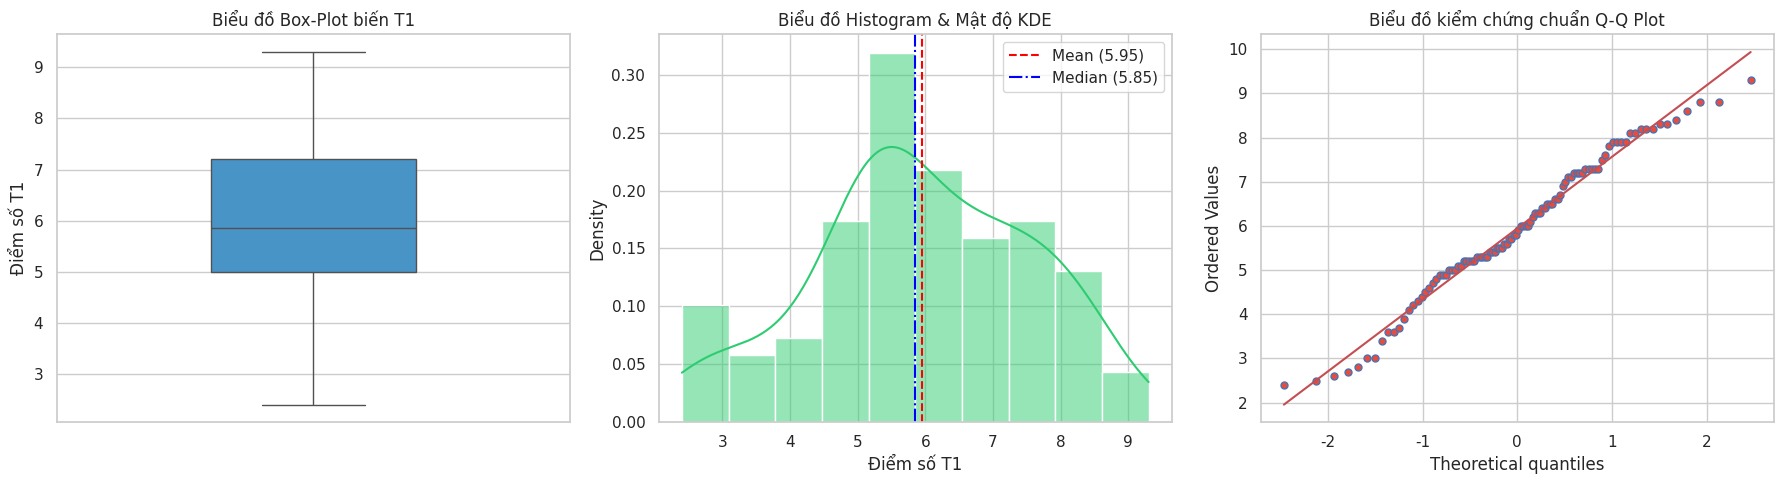


2. TRỰC QUAN HÓA THEO PHÂN NHÓM PHANLOPT1:


/tmp/ipykernel_5563/1594912256.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='phanlopt1', y='T1', order=order_categories, palette='Set2')


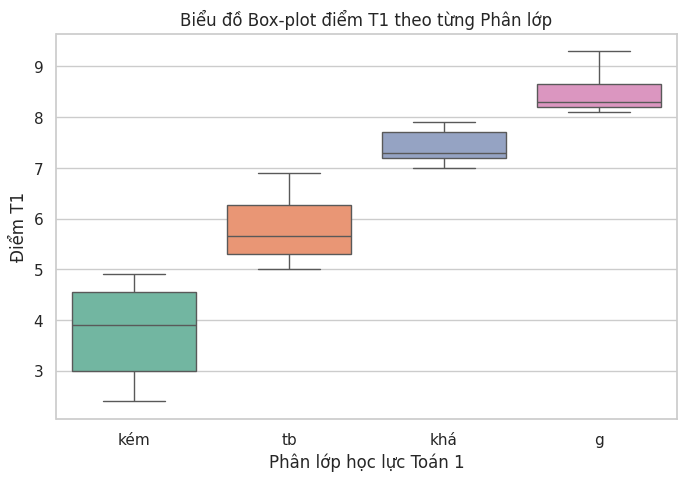

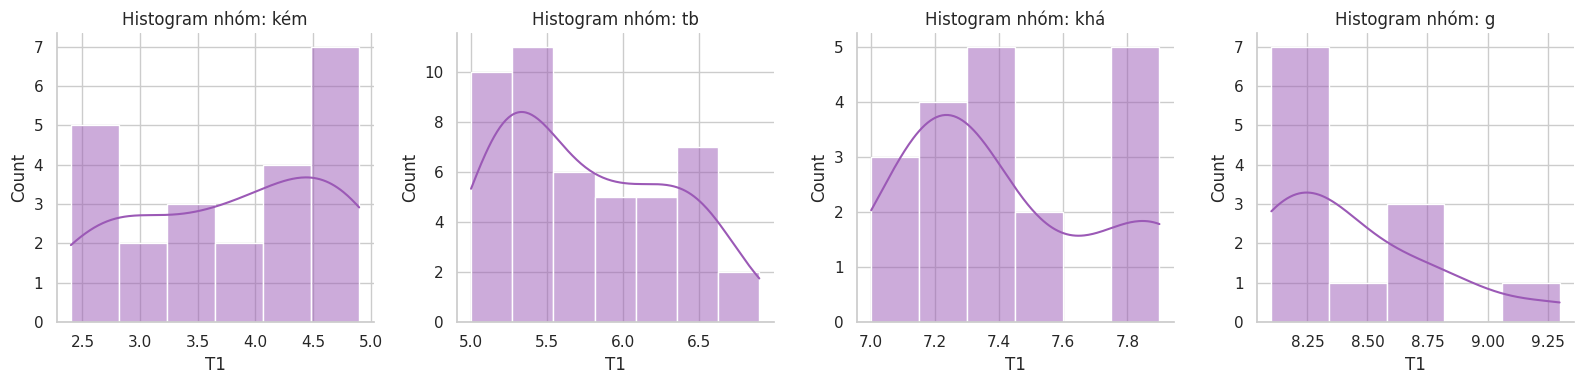


3. KHẢO SÁT TƯƠNG QUAN GIỮA DH1 (PHỤ THUỘC) VÀ T1 (ĐỘC LẬP):
- Hiệp phương sai (Covariance): 0.1128
- Hệ số tương quan Pearson (Correlation): 0.0493


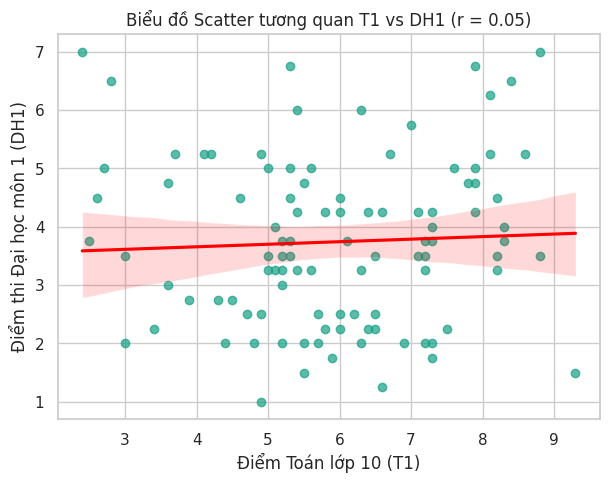


4. TƯƠNG QUAN T1 VS DH1 THEO TỪNG KHU VỰC (KV):
  + Khu vực 2NT: Hệ số tương quan r = 0.28 (Số mẫu: 21)
  + Khu vực 1: Hệ số tương quan r = -0.08 (Số mẫu: 60)
  + Khu vực 2: Hệ số tương quan r = 0.06 (Số mẫu: 19)


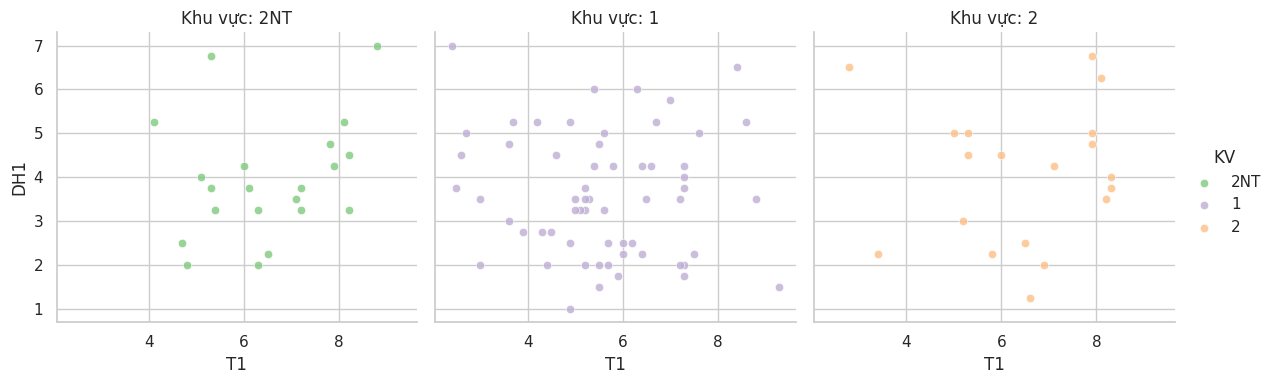


5. MA TRẬN HIỆP PHƯƠNG SAI VÀ TƯƠNG QUAN GIỮA DH1, DH2, DH3:

--- Ma trận hiệp phương sai (Covariance Matrix): ---
|     |       DH1 |        DH2 |        DH3 |
|:----|----------:|-----------:|-----------:|
| DH1 | 2.02894   |  0.0530808 |  0.0277778 |
| DH2 | 0.0530808 |  1.12371   | -0.10101   |
| DH3 | 0.0277778 | -0.10101   |  1.08396   |

--- Ma trận tương quan (Correlation Matrix): ---
|     |       DH1 |        DH2 |        DH3 |
|:----|----------:|-----------:|-----------:|
| DH1 | 1         |  0.0351541 |  0.0187308 |
| DH2 | 0.0351541 |  1         | -0.0915229 |
| DH3 | 0.0187308 | -0.0915229 |  1         |


<Figure size 800x800 with 0 Axes>

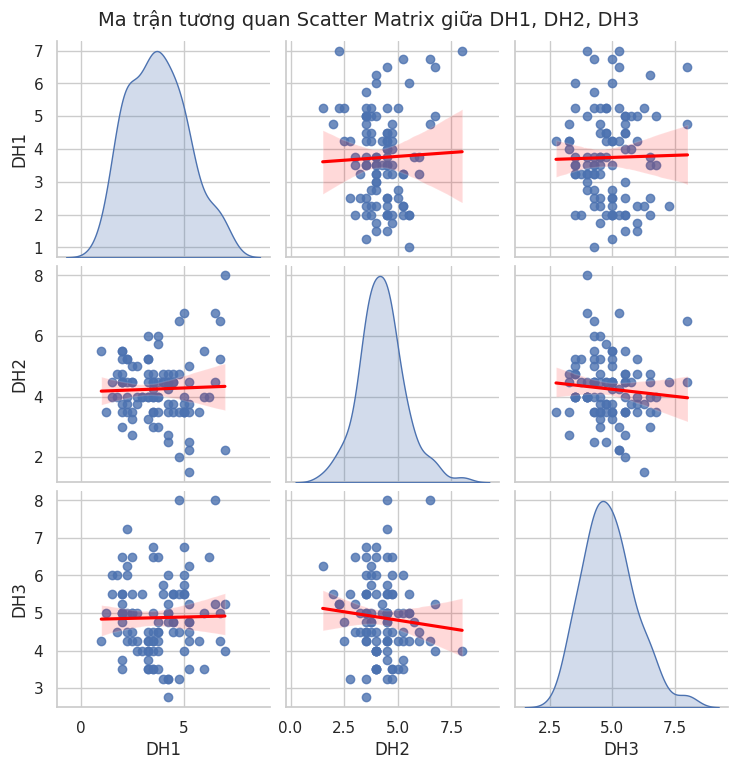


--- HOÀN THÀNH TOÀN BỘ CHƯƠNG TRÌNH KHẢO SÁT VÀ MÔ TẢ PHÂN PHỐI ---


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid")

# 0. Tải dữ liệu gốc và tạo biến phanlopt1 (để đảm bảo tính liên tục)
file_name = 'dulieuxettuyendaihoc (2).csv'
df = pd.read_csv(file_name)

def phan_lop_t1(diem):
    if diem < 5.0: return 'kém'
    elif diem < 7.0: return 'tb'
    elif diem < 8.0: return 'khá'
    else: return 'g'
df['phanlopt1'] = df['T1'].apply(phan_lop_t1)

print("="*70)
print("THỰC HIỆN PHẦN 5: MÔ TẢ DỮ LIỆU VÀ KHẢO SÁT DẠNG PHÂN PHỐI")
print("="*70)

# 1. Hãy mô tả và khảo sát phân phối cho biến T1
print("\n1. KHẢO SÁT PHÂN PHỐI CỦA BIẾN T1 (ĐIỂM TOÁN KỲ 1):")

mean_t1 = df['T1'].mean()
median_t1 = df['T1'].median()
mode_t1 = df['T1'].mode()[0]
var_t1 = df['T1'].var()
std_t1 = df['T1'].std()
skew_t1 = df['T1'].skew()
kurt_t1 = df['T1'].kurt()

min_t1 = df['T1'].min()
max_t1 = df['T1'].max()
q1_t1 = df['T1'].quantile(0.25)
q3_t1 = df['T1'].quantile(0.75)
iqr_t1 = q3_t1 - q1_t1
lower_fence = max(min_t1, q1_t1 - 1.5 * iqr_t1)
upper_fence = min(max_t1, q3_t1 + 1.5 * iqr_t1)

print(f"- Độ tập trung: Mean = {mean_t1:.2f}, Median = {median_t1:.2f}, Mode = {mode_t1:.2f}")
print(f"- Độ phân tán: Variance = {var_t1:.2f}, Std Dev = {std_t1:.2f}, IQR = {iqr_t1:.2f}")
print(f"- Hình dáng: Skewness (Độ lệch) = {skew_t1:.2f}, Kurtosis (Độ nhọn) = {kurt_t1:.2f}")
print(f"- 10 đại lượng Box-plot: Min={min_t1}, Max={max_t1}, Q1={q1_t1}, Q2(Med)={median_t1}, Q3={q3_t1}, IQR={iqr_t1:.2f}, Lower Fence={lower_fence:.2f}, Upper Fence={upper_fence:.2f}, Số lượng mẫu={len(df)}, Số lượng Outliers={( (df['T1'] < q1_t1 - 1.5*iqr_t1) | (df['T1'] > q3_t1 + 1.5*iqr_t1) ).sum()}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(y=df['T1'], ax=axes[0], color='#3498db', width=0.4)
axes[0].set_title('Biểu đồ Box-Plot biến T1')
axes[0].set_ylabel('Điểm số T1')

sns.histplot(df['T1'], kde=True, ax=axes[1], color='#2ecc71', bins=10, stat="density")
axes[1].axvline(mean_t1, color='red', linestyle='--', label=f'Mean ({mean_t1:.2f})')
axes[1].axvline(median_t1, color='blue', linestyle='-.', label=f'Median ({median_t1:.2f})')
axes[1].set_title('Biểu đồ Histogram & Mật độ KDE')
axes[1].set_xlabel('Điểm số T1')
axes[1].legend()

stats.probplot(df['T1'], dist="norm", plot=axes[2])
axes[2].get_lines()[0].set_markerfacecolor('#e74c3c')
axes[2].get_lines()[0].set_markersize(5)
axes[2].set_title('Biểu đồ kiểm chứng chuẩn Q-Q Plot')

plt.tight_layout()
plt.show()

# 2. Hãy mô tả và khảo sát phân phối cho biến T1 trên từng nhóm phân lớp (phanlopT1)
print("\n2. TRỰC QUAN HÓA THEO PHÂN NHÓM PHANLOPT1:")
order_categories = ['kém', 'tb', 'khá', 'g']

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='phanlopt1', y='T1', order=order_categories, palette='Set2')
plt.title('Biểu đồ Box-plot điểm T1 theo từng Phân lớp')
plt.xlabel('Phân lớp học lực Toán 1')
plt.ylabel('Điểm T1')
plt.show()

# Vẽ FacetGrid Histogram và Q-Q plot cho từng nhóm
g = sns.FacetGrid(df, col="phanlopt1", col_order=order_categories, sharex=False, sharey=False, height=4)
g.map(sns.histplot, "T1", kde=True, color="#9b59b6")
g.set_titles("Histogram nhóm: {col_name}")
plt.show()

# 3. Hãy khảo sát tương quan giữa biến DH1 theo biến T1
print("\n3. KHẢO SÁT TƯƠNG QUAN GIỮA DH1 (PHỤ THUỘC) VÀ T1 (ĐỘC LẬP):")
cov_t1_dh1 = df['T1'].cov(df['DH1'])
corr_t1_dh1 = df['T1'].corr(df['DH1'])
print(f"- Hiệp phương sai (Covariance): {cov_t1_dh1:.4f}")
print(f"- Hệ số tương quan Pearson (Correlation): {corr_t1_dh1:.4f}")

plt.figure(figsize=(7, 5))
sns.regplot(data=df, x='T1', y='DH1', scatter_kws={'alpha':0.7, 'color':'#16a085'}, line_kws={'color':'red'})
plt.title(f'Biểu đồ Scatter tương quan T1 vs DH1 (r = {corr_t1_dh1:.2f})')
plt.xlabel('Điểm Toán lớp 10 (T1)')
plt.ylabel('Điểm thi Đại học môn 1 (DH1)')
plt.show()

# 4. Hãy khảo sát tương quan giữa biến DH1 theo biến T1 trên từng nhóm khu vực
print("\n4. TƯƠNG QUAN T1 VS DH1 THEO TỪNG KHU VỰC (KV):")
for kv in df['KV'].unique():
    df_kv = df[df['KV'] == kv]
    if len(df_kv) > 1:
        r_kv = df_kv['T1'].corr(df_kv['DH1'])
        print(f"  + Khu vực {kv}: Hệ số tương quan r = {r_kv:.2f} (Số mẫu: {len(df_kv)})")

g_kv = sns.FacetGrid(df, col="KV", hue="KV", height=4, palette='Accent')
g_kv.map(sns.scatterplot, "T1", "DH1", alpha=0.8)
g_kv.add_legend()
g_kv.set_titles("Khu vực: {col_name}")
plt.show()


# 5. Hãy khảo sát tương quan giữa các biến DH1, DH2, DH3
print("\n5. MA TRẬN HIỆP PHƯƠNG SAI VÀ TƯƠNG QUAN GIỮA DH1, DH2, DH3:")
biens_dh = ['DH1', 'DH2', 'DH3']

matrix_cov = df[biens_dh].cov()
matrix_corr = df[biens_dh].corr()

print("\n--- Ma trận hiệp phương sai (Covariance Matrix): ---")
print(matrix_cov.to_markdown())
print("\n--- Ma trận tương quan (Correlation Matrix): ---")
print(matrix_corr.to_markdown())

plt.figure(figsize=(8, 8))
pair_plot = sns.pairplot(df[biens_dh], kind='reg', diag_kind='kde', plot_kws={'line_kws':{'color':'red'}})
pair_plot.fig.suptitle('Ma trận tương quan Scatter Matrix giữa DH1, DH2, DH3', y=1.02, fontsize=14)
plt.show()

print("\n--- HOÀN THÀNH TOÀN BỘ CHƯƠNG TRÌNH KHẢO SÁT VÀ MÔ TẢ PHÂN PHỐI ---")